# 05 - Manual Geometry Stitcher

This notebook is the final stitching step for the project-side Python pipeline. It uses the descriptors and pair scores from Notebook `04`, then builds panoramas using our own adjacent-pair geometric chain.

The default manual geometry is now **affine**, not full homography, because full chained homographies can collapse or over-stretch wide indoor sweeps. Homography is still available as an experiment, but affine/similarity are safer for the report showcase and mobile-style use.

High-level flow:

1. load ordered scene images from `data/split`
2. reuse Notebook `03` feature caches when available
3. reuse Notebook `04` pair method choices when `METHOD = "auto"`
4. match descriptors and estimate adjacent transforms with RANSAC
5. chain the adjacent transforms into one shared coordinate system
6. warp, blend, crop, and save each panorama
7. compare the manual result with OpenCV Stitcher


## 1. Setup


In [25]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import cv2
import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ModuleNotFoundError:
    plt = None
    HAS_MATPLOTLIB = False

try:
    from IPython.display import display, Markdown
except ModuleNotFoundError:
    def display(value):
        print(value)
    class Markdown:
        def __init__(self, text):
            self.text = text
        def __str__(self):
            return self.text

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


In [26]:
def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "data" / "split").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/split and scripts")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from project_utils.panorama_dataset import ordered_scene_files

# Reload the portable stitcher module so a long-lived notebook kernel does not keep
# an old PanoramaConfig class without manual_motion_model support.
import importlib
import scripts.PhamHungSon_15_portable_panorama_pipeline as panorama_pipeline
panorama_pipeline = importlib.reload(panorama_pipeline)

PanoramaConfig = panorama_pipeline.PanoramaConfig
apply_profile = panorama_pipeline.apply_profile
load_pair_method_map = panorama_pipeline.load_pair_method_map
stitch_scene_folder = panorama_pipeline.stitch_scene_folder

SPLIT_ROOT = PROJECT_ROOT / "data" / "split"
FEATURE_CACHE_ROOT = PROJECT_ROOT / "data" / "feature_extract"
PAIR_METRICS_PATH = PROJECT_ROOT / "outputs" / "batch_feature_matching" / "pair_metrics.csv"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "manual_homography_stitcher"
OUTPUT_PANORAMA_DIR = OUTPUT_ROOT / "panoramas"
OUTPUT_LOG_DIR = OUTPUT_ROOT / "logs"

OUTPUT_PANORAMA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_LOG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PAIR_METRICS_PATH:", PAIR_METRICS_PATH)
print("OUTPUT_ROOT:", OUTPUT_ROOT)


PROJECT_ROOT: C:\Users\PC\Downloads\Project
PAIR_METRICS_PATH: C:\Users\PC\Downloads\Project\outputs\batch_feature_matching\pair_metrics.csv
OUTPUT_ROOT: C:\Users\PC\Downloads\Project\outputs\manual_homography_stitcher


## 2. Configuration

Use `PROFILE = "fast"` for weak devices, `balanced` for the normal report run, and `quality` for a slower but more careful pass.

The important final-exam upgrade is `MANUAL_MOTION_MODEL = "affine"`. Earlier manual stitching used chained full homographies, which are mathematically valid but too flexible for many phone panoramas. Affine keeps the manual pipeline transparent while reducing over-warp, stretched canvas, and tunnel/hourglass artifacts. Homography remains available as a study option.

The notebook defaults to two representative scenes:

- `test/scene_01`: a normal successful scene with a serpentine/two-row capture order
- `failure_analysis/scene_15`: a hard/failure-oriented scene where partial stitching is allowed for diagnostic value


In [27]:
RUN_FULL_DATABASE = False
SELECTED_SCENES = [
    ("test", "scene_01"),
    ("failure_analysis", "scene_15"),
]

PROFILE = "balanced"          # fast, balanced, quality
METHOD = "auto"               # auto, ORB, AKAZE, SIFT
USE_NOTEBOOK04_METRICS = True
FEATURE_SOURCE = "cache"      # cache or compute; cache keeps notebook 03 -> 04 -> 05 intact
BLEND_MODE = "average"        # overwrite, average, feather
MANUAL_MOTION_MODEL = "affine" # translation, similarity, affine, homography
IMAGE_ORDER = "meta"          # meta or name; do not use mtime for copied split folders
ALLOW_PARTIAL_FAILURE_SCENES = True

# Mobile-style tuning knobs. Lower width/features means faster and lower memory.
WORK_WIDTH = 1280
MAX_FEATURES = 3000
MAX_CANVAS_MEGAPIXELS = 24.0
MAX_CANVAS_SIDE = 12000


### Scene Ordering and Scene 01 Note

Notebook `04` already evaluated each adjacent pair and method. Here we use those scores to choose a method per pair, then recompute the actual geometric transforms needed for stitching.

`scene_01` is a serpentine/two-row capture: top-left to top-right, then bottom-right to bottom-left. That order is valid only if we keep the intended filename/meta order. The copied split files have modification times in the reverse direction, so `IMAGE_ORDER = "mtime"` can silently reverse the chain.

OpenCV Stitcher can recover this scene better because it builds a broader matching/camera-estimation graph. The manual method is intentionally simpler: it follows the adjacent sequence and accumulates drift around the row turn, so visual ghosting is expected even when the pair metrics say `ok`.


In [28]:
pair_df = pd.read_csv(PAIR_METRICS_PATH)
display(pair_df.head())

display(
    pair_df.groupby(["split", "method", "status"], dropna=False)
    .size()
    .unstack(fill_value=0)
    .reset_index()
)


,split,scene_id,pair_id,pair_index,image_a,image_b,method,feature_source_a,feature_source_b,feature_file_a,feature_file_b,keypoints_a,keypoints_b,raw_matches,good_matches,lowe_pass_rate,median_lowe_ratio,homography_ok,inliers,inlier_ratio,reprojection_error_mean,reprojection_error_median,coverage_a,coverage_b,coverage_min,feature_runtime_sec,status,category,difficulty,recommended_use,used_meta_order,error
0,test,scene_01,pair_01,1,img_01.jpg,img_02.jpg,ORB,cache,cache,data/feature_extract/test/scene_01/ORB/feature...,data/feature_extract/test/scene_01/ORB/feature...,4000,4000,4000,1015,0.25375,0.878788,True,771,0.759606,1.348110,1.166860,0.338059,0.317290,0.317290,0.125234,success,success,medium,core_benchmark,True,NaN
1,test,scene_01,pair_02,2,img_02.jpg,img_03.jpg,ORB,cache,cache,data/feature_extract/test/scene_01/ORB/feature...,data/feature_extract/test/scene_01/ORB/feature...,4000,4000,4000,678,0.16950,0.914286,True,426,0.628319,1.298061,1.081087,0.258384,0.290606,0.258384,0.129681,success,success,medium,core_benchmark,True,NaN
2,test,scene_01,pair_03,3,img_03.jpg,img_04.jpg,ORB,cache,cache,data/feature_extract/test/scene_01/ORB/feature...,data/feature_extract/test/scene_01/ORB/feature...,4000,4000,4000,550,0.13750,0.934211,True,322,0.585455,1.158818,1.029856,0.362537,0.368323,0.362537,0.127339,success,success,medium,core_benchmark,True,NaN
3,test,scene_01,pair_04,4,img_04.jpg,img_05.jpg,ORB,cache,cache,data/feature_extract/test/scene_01/ORB/feature...,data/feature_extract/test/scene_01/ORB/feature...,4000,4000,4000,325,0.08125,0.951220,True,274,0.843077,0.910525,0.768282,0.163801,0.151390,0.151390,0.129148,success,success,medium,core_benchmark,True,NaN
4,test,scene_01,pair_05,5,img_05.jpg,img_06.jpg,ORB,cache,cache,data/feature_extract/test/scene_01/ORB/feature...,data/feature_extract/test/scene_01/ORB/feature...,4000,3810,4000,599,0.14975,0.921875,True,414,0.691152,1.277043,1.137123,0.118296,0.138442,0.118296,0.129880,success,success,medium,core_benchmark,True,NaN


status,split,method,failure,hard_valid,success
0,failure_analysis,AKAZE,7,6,42
1,failure_analysis,HARRIS_HOG,10,10,35
2,failure_analysis,ORB,7,2,46
3,failure_analysis,SIFT,6,8,41
4,test,AKAZE,0,0,30
5,test,HARRIS_HOG,2,5,23
6,test,ORB,0,2,28
7,test,SIFT,1,1,28


## 4. Scene Selection


In [29]:
def scene_sort_key(scene_id: str) -> tuple[int, str]:
    digits = "".join(ch for ch in scene_id if ch.isdigit())
    return (int(digits) if digits else 10**9, scene_id)


def all_database_scenes() -> list[tuple[str, str]]:
    records = []
    for split_name in ["test", "failure_analysis"]:
        split_dir = SPLIT_ROOT / split_name
        for scene_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()], key=lambda p: scene_sort_key(p.name)):
            records.append((split_name, scene_dir.name))
    return records


scene_records = all_database_scenes() if RUN_FULL_DATABASE else SELECTED_SCENES
print("Scene count:", len(scene_records))
display(pd.DataFrame(scene_records, columns=["split", "scene_id"]))


Scene count: 2


,split,scene_id
0,test,scene_01
1,failure_analysis,scene_15


## 5. Run Manual Stitcher

The function below calls the portable manual stitcher directly. For project scenes it passes the split name, scene id, feature-cache root, image ordering mode, manual motion model, and the notebook `04` pair-method map.


In [30]:
def make_config(split_name: str, scene_id: str) -> PanoramaConfig:
    config = PanoramaConfig(
        engine="manual",
        profile=PROFILE,
        method=METHOD,
        manual_motion_model=MANUAL_MOTION_MODEL,
        image_order=IMAGE_ORDER,
        work_width=WORK_WIDTH,
        max_features=MAX_FEATURES,
        blend_mode=BLEND_MODE,
        allow_partial=ALLOW_PARTIAL_FAILURE_SCENES and split_name == "failure_analysis",
        max_canvas_megapixels=MAX_CANVAS_MEGAPIXELS,
        max_canvas_side=MAX_CANVAS_SIDE,
        feature_cache_root=str(FEATURE_CACHE_ROOT),
        split_name=split_name,
        scene_id=scene_id,
        prefer_cache=FEATURE_SOURCE == "cache",
    )
    config = apply_profile(config)
    if USE_NOTEBOOK04_METRICS and config.method == "auto":
        config.pair_method_map = load_pair_method_map(
            PAIR_METRICS_PATH,
            split_name,
            scene_id,
            config.candidate_methods,
        )
    return config


def run_manual_scene(split_name: str, scene_id: str) -> dict:
    scene_dir = SPLIT_ROOT / split_name / scene_id
    panorama_path = OUTPUT_PANORAMA_DIR / split_name / f"{scene_id}_manual_homography.jpg"
    log_path = OUTPUT_LOG_DIR / split_name / f"{scene_id}_manual_homography.json"
    config = make_config(split_name, scene_id)
    try:
        payload = stitch_scene_folder(scene_dir, panorama_path, config, log_path)
        panorama_shape = payload.get("panorama_shape", {})
        return {
            "split": split_name,
            "scene_id": scene_id,
            "status": payload["status"],
            "is_partial": payload.get("is_partial", False),
            "image_count": payload["image_count"],
            "runtime_sec": payload["runtime_sec"],
            "manual_motion_model": payload.get("config", {}).get("manual_motion_model", MANUAL_MOTION_MODEL),
            "image_order": payload.get("config", {}).get("image_order", IMAGE_ORDER),
            "panorama_shape": f"{panorama_shape.get('width', '')}x{panorama_shape.get('height', '')}",
            "panorama_path": str(panorama_path.relative_to(PROJECT_ROOT)),
            "log_path": str(log_path.relative_to(PROJECT_ROOT)),
            "error": "",
        }
    except Exception as exc:
        return {
            "split": split_name,
            "scene_id": scene_id,
            "status": "failed",
            "is_partial": "",
            "image_count": 0,
            "runtime_sec": np.nan,
            "manual_motion_model": MANUAL_MOTION_MODEL,
            "image_order": IMAGE_ORDER,
            "panorama_shape": "",
            "panorama_path": str(panorama_path.relative_to(PROJECT_ROOT)),
            "log_path": str(log_path.relative_to(PROJECT_ROOT)),
            "error": str(exc),
        }


manual_rows = [run_manual_scene(split_name, scene_id) for split_name, scene_id in scene_records]
manual_df = pd.DataFrame(manual_rows)
manual_summary_path = OUTPUT_ROOT / "notebook05_manual_stitch_summary.csv"
manual_df.to_csv(manual_summary_path, index=False, encoding="utf-8-sig")
print("Saved:", manual_summary_path.relative_to(PROJECT_ROOT))
display(manual_df)


Saved: outputs\manual_homography_stitcher\notebook05_manual_stitch_summary.csv


,split,scene_id,status,is_partial,image_count,runtime_sec,manual_motion_model,image_order,panorama_shape,panorama_path,log_path,error
0,test,scene_01,ok,False,6,3.036313,affine,meta,3105x1378,outputs\manual_homography_stitcher\panoramas\t...,outputs\manual_homography_stitcher\logs\test\s...,
1,failure_analysis,scene_15,ok,False,5,1.413966,affine,meta,2856x816,outputs\manual_homography_stitcher\panoramas\f...,outputs\manual_homography_stitcher\logs\failur...,


## 6. Motion Model Upgrade Diagnostic

The manual stitcher is no longer presented as a pure homography-chain method. The final showcase uses an affine chain by default because it is less likely to overfit local matches and distort the whole canvas.

This diagnostic cell runs the same scene through several manual motion models and saves the results under `outputs/manual_homography_stitcher/motion_model_diagnostic/`. For `scene_01`, which is a top-left to top-right, then bottom-right to bottom-left serpentine capture, this section is important: full homography can still report strong inlier statistics but produce a visually worse panorama because the projective warp is too flexible when chained across a row turn.


,split,scene_id,motion_model,status,is_partial,used_images,panorama_shape,mean_inlier_ratio,mean_reprojection_error,nonblack_coverage,runtime_sec,panorama_path,log_path,error
0,test,scene_01,similarity,ok,False,6,3193x1466,0.3870,1.9074,0.7239,3.120,outputs\manual_homography_stitcher\motion_mode...,outputs\manual_homography_stitcher\motion_mode...,
1,test,scene_01,affine,ok,False,6,3105x1378,0.4717,1.7128,0.7498,2.990,outputs\manual_homography_stitcher\motion_mode...,outputs\manual_homography_stitcher\motion_mode...,
2,test,scene_01,homography,ok,False,6,7609x3155,0.7015,1.1985,0.4551,6.585,outputs\manual_homography_stitcher\motion_mode...,outputs\manual_homography_stitcher\motion_mode...,


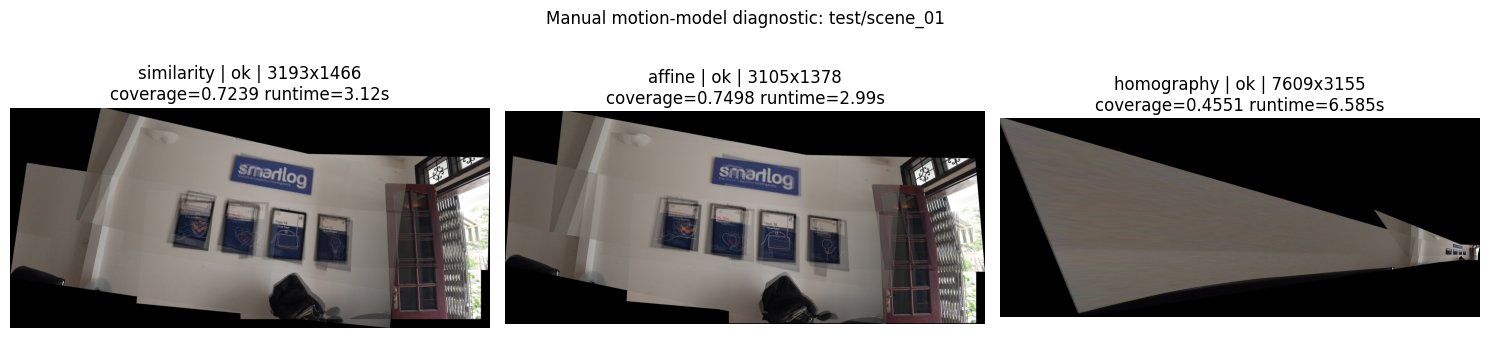

In [31]:
RUN_MOTION_MODEL_DIAGNOSTIC = True
MOTION_MODEL_DIAGNOSTIC_SCENES = [("test", "scene_01")]
DIAGNOSTIC_MOTION_MODELS = ["similarity", "affine", "homography"]
MOTION_DIAGNOSTIC_ROOT = OUTPUT_ROOT / "motion_model_diagnostic"


def image_nonblack_coverage(path: Path) -> float:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        return np.nan
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return float((gray > 5).mean())


def run_motion_model_diagnostic(split_name: str, scene_id: str, motion_model: str) -> dict:
    scene_dir = SPLIT_ROOT / split_name / scene_id
    out_dir = MOTION_DIAGNOSTIC_ROOT / split_name / scene_id
    out_dir.mkdir(parents=True, exist_ok=True)

    panorama_path = out_dir / f"{scene_id}_{motion_model}.jpg"
    log_path = out_dir / f"{scene_id}_{motion_model}.json"

    config = make_config(split_name, scene_id)
    config.manual_motion_model = motion_model
    config.allow_partial = ALLOW_PARTIAL_FAILURE_SCENES and split_name == "failure_analysis"

    try:
        payload = stitch_scene_folder(scene_dir, panorama_path, config, log_path)
        pairs = payload.get("pairs", [])
        inlier_ratios = [float(pair.get("inlier_ratio")) for pair in pairs if pair.get("inlier_ratio") is not None]
        reproj_errors = [
            float(pair.get("reprojection_error_mean"))
            for pair in pairs
            if pair.get("reprojection_error_mean") is not None
        ]
        shape = payload.get("panorama_shape", {})
        return {
            "split": split_name,
            "scene_id": scene_id,
            "motion_model": motion_model,
            "status": payload.get("status"),
            "is_partial": payload.get("is_partial", False),
            "used_images": payload.get("image_count", ""),
            "panorama_shape": f"{shape.get('width', '')}x{shape.get('height', '')}",
            "mean_inlier_ratio": round(float(np.mean(inlier_ratios)), 4) if inlier_ratios else np.nan,
            "mean_reprojection_error": round(float(np.mean(reproj_errors)), 4) if reproj_errors else np.nan,
            "nonblack_coverage": round(image_nonblack_coverage(panorama_path), 4),
            "runtime_sec": round(float(payload.get("runtime_sec", np.nan)), 3),
            "panorama_path": str(panorama_path.relative_to(PROJECT_ROOT)),
            "log_path": str(log_path.relative_to(PROJECT_ROOT)),
            "error": "",
        }
    except Exception as exc:
        return {
            "split": split_name,
            "scene_id": scene_id,
            "motion_model": motion_model,
            "status": "failed",
            "is_partial": "",
            "used_images": "",
            "panorama_shape": "",
            "mean_inlier_ratio": np.nan,
            "mean_reprojection_error": np.nan,
            "nonblack_coverage": np.nan,
            "runtime_sec": np.nan,
            "panorama_path": str(panorama_path.relative_to(PROJECT_ROOT)),
            "log_path": str(log_path.relative_to(PROJECT_ROOT)),
            "error": str(exc),
        }


if RUN_MOTION_MODEL_DIAGNOSTIC:
    motion_rows = []
    for split_name, scene_id in MOTION_MODEL_DIAGNOSTIC_SCENES:
        for motion_model in DIAGNOSTIC_MOTION_MODELS:
            motion_rows.append(run_motion_model_diagnostic(split_name, scene_id, motion_model))
    motion_model_df = pd.DataFrame(motion_rows)
    display(motion_model_df)

    if HAS_MATPLOTLIB and not motion_model_df.empty:
        for (split_name, scene_id), group in motion_model_df.groupby(["split", "scene_id"]):
            fig, axes = plt.subplots(1, len(group), figsize=(5 * len(group), 4))
            if len(group) == 1:
                axes = [axes]
            for ax, (_, row) in zip(axes, group.iterrows()):
                image = cv2.imread(str(PROJECT_ROOT / row["panorama_path"]), cv2.IMREAD_COLOR)
                if image is None:
                    ax.text(0.5, 0.5, "missing", ha="center", va="center")
                    ax.axis("off")
                    continue
                ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
                ax.set_title(
                    f"{row['motion_model']} | {row['status']} | {row['panorama_shape']}\n"
                    f"coverage={row['nonblack_coverage']} runtime={row['runtime_sec']}s"
                )
                ax.axis("off")
            fig.suptitle(f"Manual motion-model diagnostic: {split_name}/{scene_id}")
            plt.tight_layout()
            plt.show()
else:
    display(Markdown("Motion-model diagnostic is disabled."))


## 7. Inspect Pair Transforms

The JSON log stores each adjacent pair, selected method, motion model, RANSAC inliers, inlier ratio, reprojection error, and transform matrix. This is the clearest evidence that the panorama comes from our own geometric chain rather than OpenCV's hidden Stitcher pipeline.


In [32]:
def load_pair_log(row: pd.Series) -> pd.DataFrame:
    log_path = PROJECT_ROOT / row["log_path"]
    if not log_path.exists():
        return pd.DataFrame()
    payload = json.loads(log_path.read_text(encoding="utf-8"))
    pair_rows = []
    for pair in payload.get("pairs", []):
        pair_rows.append(
            {
                "split": row["split"],
                "scene_id": row["scene_id"],
                "pair_id": pair.get("pair_id"),
                "method": pair.get("method"),
                "motion_model": pair.get("motion_model"),
                "status": pair.get("status"),
                "good_matches": pair.get("good_matches"),
                "inliers": pair.get("inliers"),
                "inlier_ratio": pair.get("inlier_ratio"),
                "reprojection_error_mean": pair.get("reprojection_error_mean"),
            }
        )
    return pd.DataFrame(pair_rows)

pair_log_df = pd.concat([load_pair_log(row) for _, row in manual_df.iterrows()], ignore_index=True)
display(pair_log_df)


,split,scene_id,pair_id,method,motion_model,status,good_matches,inliers,inlier_ratio,reprojection_error_mean
0,test,scene_01,pair_01,ORB,affine,success,1015,450,0.443350,1.791115
1,test,scene_01,pair_02,ORB,affine,hard_valid,678,224,0.330383,1.721577
2,test,scene_01,pair_03,ORB,affine,success,550,341,0.620000,1.447983
3,test,scene_01,pair_04,ORB,affine,success,325,172,0.529231,1.749317
4,test,scene_01,pair_05,ORB,affine,success,599,261,0.435726,1.854011
5,failure_analysis,scene_15,pair_01,ORB,affine,success,127,55,0.433071,0.789770
6,failure_analysis,scene_15,pair_02,AKAZE,affine,hard_valid,319,108,0.338558,1.900612
7,failure_analysis,scene_15,pair_03,AKAZE,affine,hard_valid,320,95,0.296875,1.676270
8,failure_analysis,scene_15,pair_04,ORB,affine,success,426,180,0.422535,1.088967


## 8. Visual Results


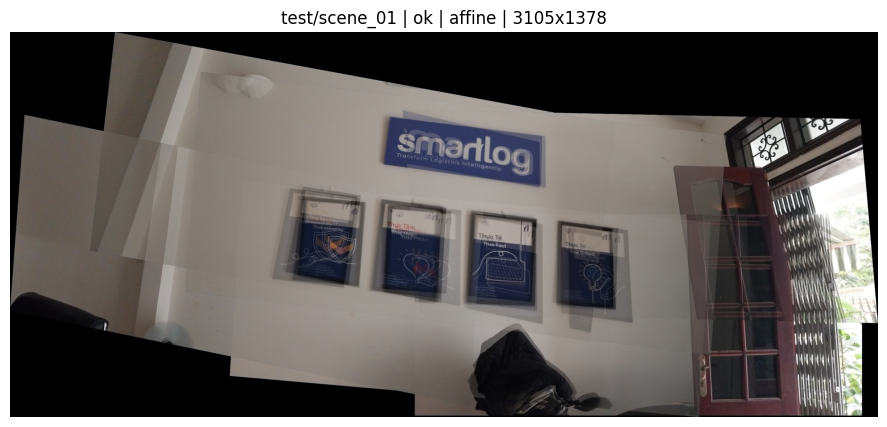

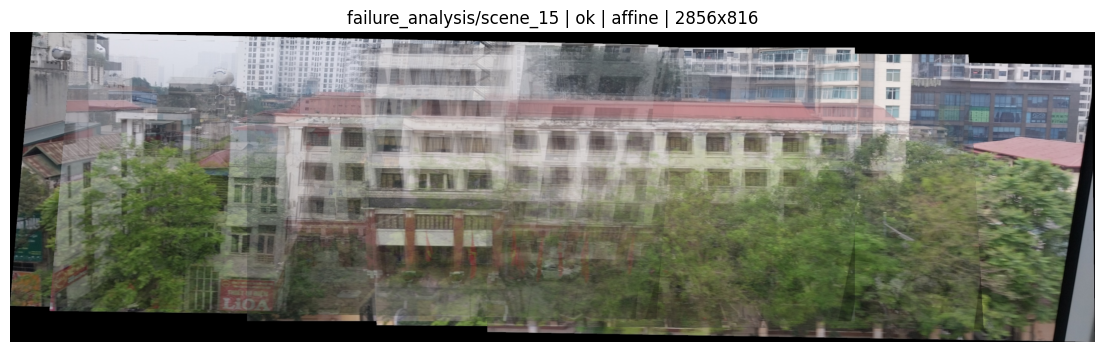

In [33]:
def show_panorama(row: pd.Series) -> None:
    path = PROJECT_ROOT / row["panorama_path"]
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        print("Missing panorama:", path)
        return
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 5))
    plt.imshow(rgb)
    plt.axis("off")
    plt.title(f"{row['split']}/{row['scene_id']} | {row['status']} | {row.get('manual_motion_model', MANUAL_MOTION_MODEL)} | {image.shape[1]}x{image.shape[0]}")
    plt.show()


if HAS_MATPLOTLIB:
    for _, row in manual_df[manual_df["status"] == "ok"].iterrows():
        show_panorama(row)
else:
    display(manual_df[["split", "scene_id", "panorama_path"]])


This manual stitcher is intentionally simpler than OpenCV Stitcher:

- it estimates only adjacent-pair transforms
- it does not build a global image graph
- it does not run camera bundle adjustment
- it does not estimate exposure compensation
- it uses simple overwrite/average/feather blending

Therefore, scenes with serpentine capture order, repeated posters, parallax, exposure change, or strong row turns may still be useful diagnostic outputs even when OpenCV produces a cleaner panorama.


## 9. Manual vs OpenCV Stitcher Comparison

This section compares the manual adjacent-transform stitcher with OpenCV's built-in `cv2.Stitcher`. The comparison uses the OpenCV batch summary from Notebook 06 and every manual stitcher log currently available under `outputs/manual_homography_stitcher/logs`.

The labels distinguish full panoramas from partial manual outputs. This matters because the manual method can still save a valid contiguous sub-chain when OpenCV rejects the whole scene, but that is not the same as a complete global panorama.


In [34]:
import subprocess

COMPARISON_SCRIPT = PROJECT_ROOT / "scripts" / "PhamHungSon_15_compare_manual_opencv_stitching.py"
COMPARISON_OUTPUT_DIR = OUTPUT_ROOT / "comparison"
COMPARISON_SPLITS = ["test", "failure_analysis"]

cmd = [
    sys.executable,
    str(COMPARISON_SCRIPT),
    "--output-dir",
    str(COMPARISON_OUTPUT_DIR),
    "--side-by-side-limit",
    "1000",  # high cap so every showcase scene gets a side-by-side panorama panel
]
for split_name in COMPARISON_SPLITS:
    cmd.extend(["--split", split_name])
completed = subprocess.run(cmd, cwd=PROJECT_ROOT, capture_output=True, text=True)
print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("Manual-vs-OpenCV comparison failed")

comparison_csv = COMPARISON_OUTPUT_DIR / "manual_vs_opencv_comparison.csv"
comparison_df = pd.read_csv(comparison_csv)
display(
    comparison_df.groupby(["split", "comparison_status"], dropna=False)
    .size()
    .rename("scene_count")
    .reset_index()
)

display(
    comparison_df[[
        "split",
        "scene_id",
        "comparison_status",
        "opencv_status_name",
        "manual_status",
        "manual_motion_model",
        "opencv_num_images",
        "manual_image_count",
        "manual_mean_inlier_ratio",
        "manual_mean_reprojection_error",
        "area_ratio_manual_over_opencv",
    ]]
)


Comparison rows: 19
CSV: C:\Users\PC\Downloads\Project\outputs\manual_homography_stitcher\comparison\manual_vs_opencv_comparison.csv
Summary: C:\Users\PC\Downloads\Project\outputs\manual_homography_stitcher\comparison\manual_vs_opencv_summary.md
Status counts: {'both_ok': 11, 'manual_partial_only': 1, 'manual_only': 4, 'both_failed_or_missing': 1, 'both_ok_manual_partial': 2}



,split,comparison_status,scene_count
0,failure_analysis,both_failed_or_missing,1
1,failure_analysis,both_ok,8
2,failure_analysis,manual_only,3
3,failure_analysis,manual_partial_only,1
4,test,both_ok,3
5,test,both_ok_manual_partial,2
6,test,manual_only,1


,split,scene_id,comparison_status,opencv_status_name,manual_status,manual_motion_model,opencv_num_images,manual_image_count,manual_mean_inlier_ratio,manual_mean_reprojection_error,area_ratio_manual_over_opencv
0,failure_analysis,scene_03,both_ok,OK,ok,affine,4,4.0,0.3854,1.6312,0.3229
1,failure_analysis,scene_04,manual_partial_only,ERR_NEED_MORE_IMGS,ok,affine,3,2.0,0.3415,1.4235,NaN
2,failure_analysis,scene_06,both_ok,OK,ok,affine,5,5.0,0.7130,1.7400,1.3536
3,failure_analysis,scene_07,both_ok,OK,ok,affine,6,6.0,0.6369,1.6768,1.3384
4,failure_analysis,scene_08,manual_only,ERR_NEED_MORE_IMGS,ok,affine,3,3.0,0.5454,1.7062,NaN
5,failure_analysis,scene_11,manual_only,ERR_NEED_MORE_IMGS,ok,affine,3,3.0,0.5054,1.3044,NaN
6,failure_analysis,scene_15,manual_only,ERR_NEED_MORE_IMGS,ok,affine,5,5.0,0.3728,1.3639,NaN
7,failure_analysis,scene_16,both_ok,OK,ok,affine,4,4.0,0.5041,1.9544,1.9144
8,failure_analysis,scene_18,both_failed_or_missing,ERR_NEED_MORE_IMGS,failed,affine,7,NaN,NaN,NaN,NaN
9,failure_analysis,scene_21,both_ok,OK,ok,affine,13,13.0,0.4704,1.5267,1.6635


### 9.1 Failure Scene Problems vs Stitching Results

The problem labels shown here come from each `data/split/failure_analysis/<scene>/meta.json` file. They are project audit labels (`issues` and `has_*` flags), not labels returned directly by OpenCV.

The next cell joins those scene problems with the actual manual-vs-OpenCV stitching results and saves a report-ready summary under `outputs/failure_problem_analysis/`. The final comparison cell also prints a short problem note before every stitched panorama panel, so the visual result and the expected artifact are next to each other.

Scenes summarized: 13
CSV: C:\Users\PC\Downloads\Project\outputs\failure_problem_analysis\failure_problem_stitching_summary.csv
JSON: C:\Users\PC\Downloads\Project\outputs\failure_problem_analysis\failure_problem_stitching_summary.json
Markdown: C:\Users\PC\Downloads\Project\outputs\failure_problem_analysis\failure_problem_stitching_summary.md
Problem counts: C:\Users\PC\Downloads\Project\outputs\failure_problem_analysis\failure_problem_status_counts.csv
Plot: C:\Users\PC\Downloads\Project\outputs\failure_problem_analysis\failure_problem_status_counts.png



#### Failure-analysis problem coverage

,problem,scene_count,both_failed_or_missing,both_ok,manual_only,manual_partial_only,opencv_ERR_NEED_MORE_IMGS,opencv_OK
0,camera_translation,1,0,1,0,0,0,1
1,exposure_change,2,0,2,0,0,0,2
2,exposure_compensation,1,1,0,0,0,1,0
3,global_stitch_failure,1,0,0,1,0,1,0
4,horizontal_camera_motion,1,0,1,0,0,0,1
5,insufficient_global_connectivity,1,0,0,1,0,1,0
6,insufficient_overlap,2,0,0,1,1,2,0
7,low_light,1,1,0,0,0,1,0
8,low_texture,4,1,2,1,0,2,2
9,motion_blur,1,0,1,0,0,0,1


#### Problem tags joined with stitching outputs

,scene_id,category,issues,comparison_status,opencv_status_name,manual_image_coverage,manual_mean_inlier_ratio,manual_mean_reprojection_error,manual_panorama_shape,opencv_panorama_shape,observed_stitching_result,likely_glitch_or_error
0,scene_03,hard_valid,"wrong_image_order, sequence_order_error, outpu...",both_ok,OK,4/4,0.3854,1.6312,3145x808,5649x1393,OpenCV and manual both produced panoramas; com...,different runs can produce different crops or ...
1,scene_04,failure,insufficient_overlap,manual_partial_only,ERR_NEED_MORE_IMGS,2/3,0.3415,1.4235,1783x834,NaN,OpenCV returned ERR_NEED_MORE_IMGS; manual sav...,"broken image chain, ERR_NEED_MORE_IMGS, missin..."
2,scene_06,hard_valid,"sky_dominance, low_texture",both_ok,OK,5/5,0.7130,1.7400,2200x2219,1958x1842,OpenCV and manual both produced panoramas; com...,"few stable anchors, unstable homography, stret..."
3,scene_07,hard_valid,"zoom_change, scale_change",both_ok,OK,6/6,0.6369,1.6768,2580x3122,2375x2534,OpenCV and manual both produced panoramas; com...,NaN
4,scene_08,failure,global_stitch_failure,manual_only,ERR_NEED_MORE_IMGS,3/3,0.5454,1.7062,3729x3663,NaN,OpenCV returned ERR_NEED_MORE_IMGS; manual pro...,good adjacent matches can still be rejected du...
5,scene_11,failure,low_texture,manual_only,ERR_NEED_MORE_IMGS,3/3,0.5054,1.3044,2847x3710,NaN,OpenCV returned ERR_NEED_MORE_IMGS; manual pro...,"few stable anchors, unstable homography, stret..."
6,scene_15,failure,"insufficient_global_connectivity, insufficient...",manual_only,ERR_NEED_MORE_IMGS,5/5,0.3728,1.3639,2856x816,NaN,OpenCV returned ERR_NEED_MORE_IMGS; manual pro...,"local pairs may connect, but the whole scene c..."
7,scene_16,hard_valid,"camera_translation, vertical_camera_motion, ho...",both_ok,OK,4/4,0.5041,1.9544,2013x2733,1353x2124,OpenCV and manual both produced panoramas; com...,"ghosting, bent structures, doubled edges, and ..."
8,scene_18,failure,"low_light, exposure_compensation, underexposur...",both_failed_or_missing,ERR_NEED_MORE_IMGS,NaN,NaN,NaN,NaN,NaN,OpenCV status=ERR_NEED_MORE_IMGS; manual statu...,"few stable anchors, unstable homography, stret..."
9,scene_21,hard_valid,"exposure_change, low_texture, wide_sweep",both_ok,OK,13/13,0.4704,1.5267,6995x3431,3992x3614,OpenCV and manual both produced panoramas; com...,visible brightness seams and inconsistent pano...


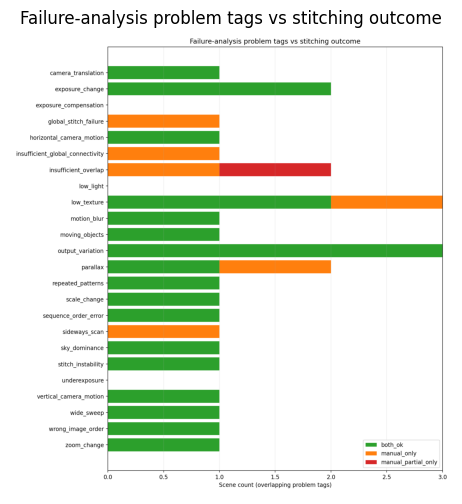

In [35]:
import subprocess

FAILURE_PROBLEM_SCRIPT = PROJECT_ROOT / "scripts" / "PhamHungSon_15_summarize_failure_problem_stitching.py"
FAILURE_PROBLEM_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "failure_problem_analysis"

cmd = [
    sys.executable,
    str(FAILURE_PROBLEM_SCRIPT),
    "--output-dir",
    str(FAILURE_PROBLEM_OUTPUT_DIR),
]
completed = subprocess.run(cmd, cwd=PROJECT_ROOT, capture_output=True, text=True)
print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("Failure-problem stitching summary failed")

failure_problem_csv = FAILURE_PROBLEM_OUTPUT_DIR / "failure_problem_stitching_summary.csv"
problem_counts_csv = FAILURE_PROBLEM_OUTPUT_DIR / "failure_problem_status_counts.csv"
problem_plot_path = FAILURE_PROBLEM_OUTPUT_DIR / "failure_problem_status_counts.png"

failure_problem_df = pd.read_csv(failure_problem_csv)
problem_counts_df = pd.read_csv(problem_counts_csv)

display(Markdown("#### Failure-analysis problem coverage"))
display(problem_counts_df)

display(Markdown("#### Problem tags joined with stitching outputs"))
display(
    failure_problem_df[[
        "scene_id",
        "category",
        "issues",
        "comparison_status",
        "opencv_status_name",
        "manual_image_coverage",
        "manual_mean_inlier_ratio",
        "manual_mean_reprojection_error",
        "manual_panorama_shape",
        "opencv_panorama_shape",
        "observed_stitching_result",
        "likely_glitch_or_error",
    ]]
)

if HAS_MATPLOTLIB and problem_plot_path.exists():
    image = cv2.imread(str(problem_plot_path), cv2.IMREAD_COLOR)
    if image is not None:
        plt.figure(figsize=(12, 6))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title("Failure-analysis problem tags vs stitching outcome")
        plt.show()

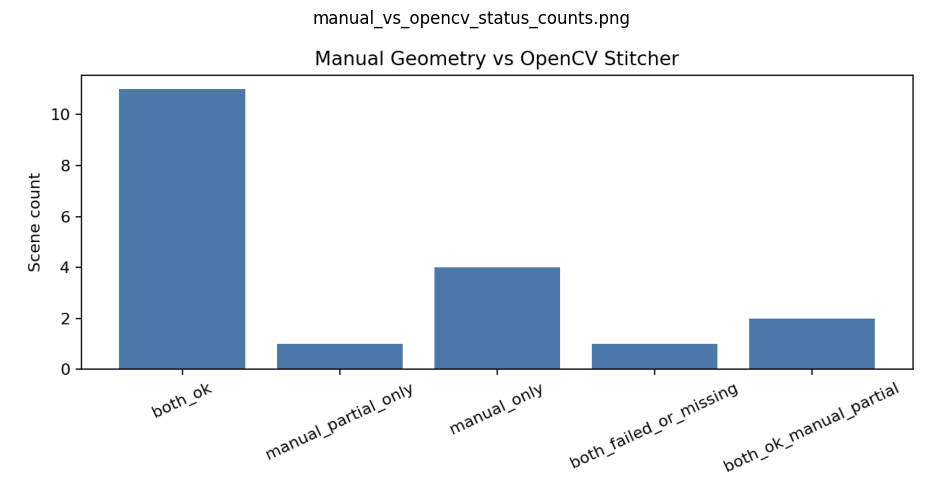

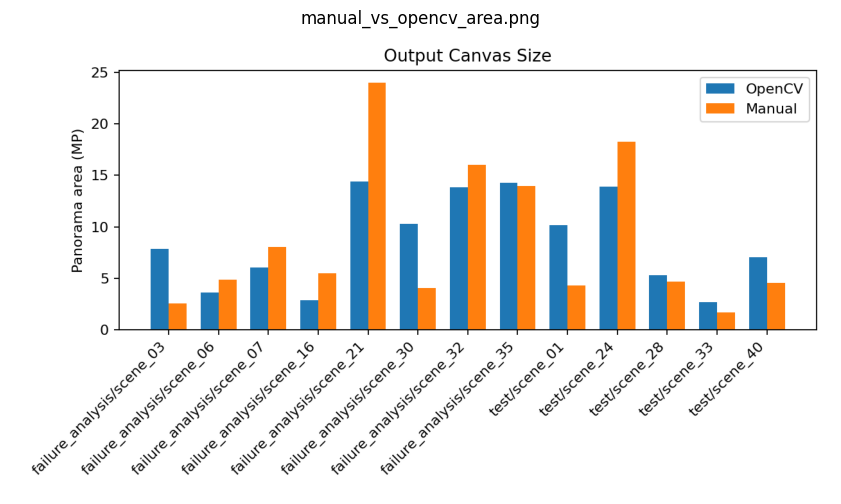

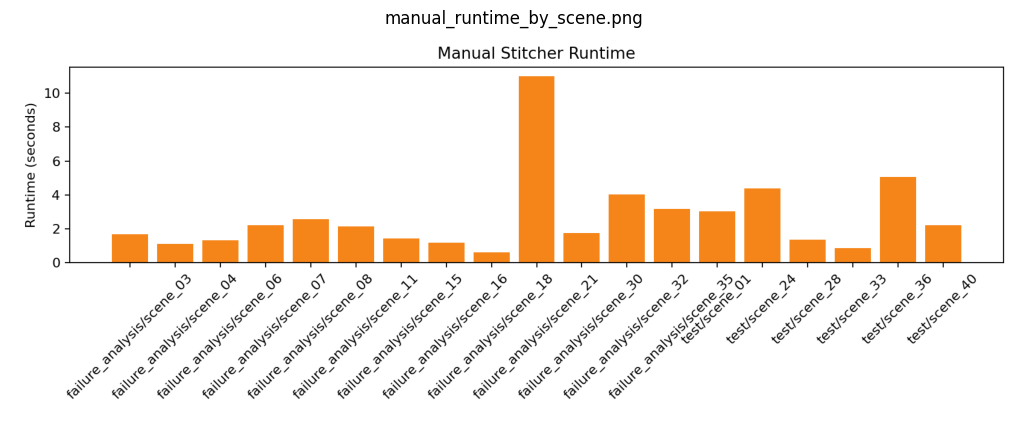

### Showing all 19 stitched panorama comparison panels with scene-problem notes

#### `failure_analysis/scene_03` | comparison: `both_ok`

**Scene problems:** wrong_image_order, sequence_order_error, output_variation  
**Scene category:** `hard_valid`  
**Observed stitching result:** OpenCV and manual both produced panoramas; compare seams, canvas size, drift, and ghosting visually.  
**Artifact/glitch to inspect:** different runs can produce different crops or output sizes; successful stitch still needs visual inspection because output footprint varies  
**Scene notes:** Derived from development/scene_03 by intentionally swapping the final two frames in the filename order. The wrong order degrades the sequential pair audit and creates output variation, but OpenCV still stitches all repeated runs because the original scene has strong overlap; use this as a controlled wrong-image-order stress case rather than a natural capture failure.

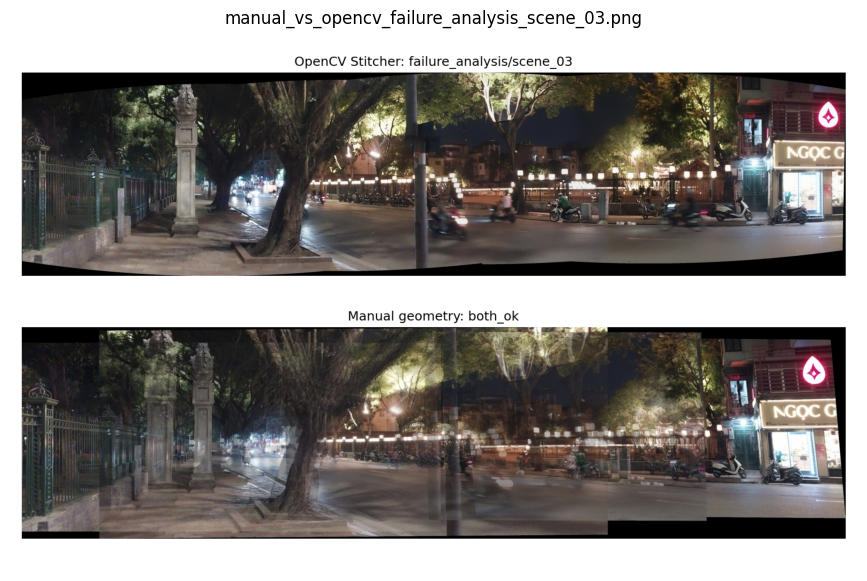

#### `failure_analysis/scene_04` | comparison: `manual_partial_only`

**Scene problems:** insufficient_overlap  
**Scene category:** `failure`  
**Observed stitching result:** OpenCV returned ERR_NEED_MORE_IMGS; manual saved only a contiguous partial chain (2/3).  
**Artifact/glitch to inspect:** broken image chain, ERR_NEED_MORE_IMGS, missing regions, or forced narrow manual output; partial output means at least one adjacent transition was rejected  
**Scene notes:** Short outdoor wall and rooftop sequence with weak continuity between adjacent views. The chain does not share enough usable content to recover a reliable panorama, so it stays a clean overlap failure case.

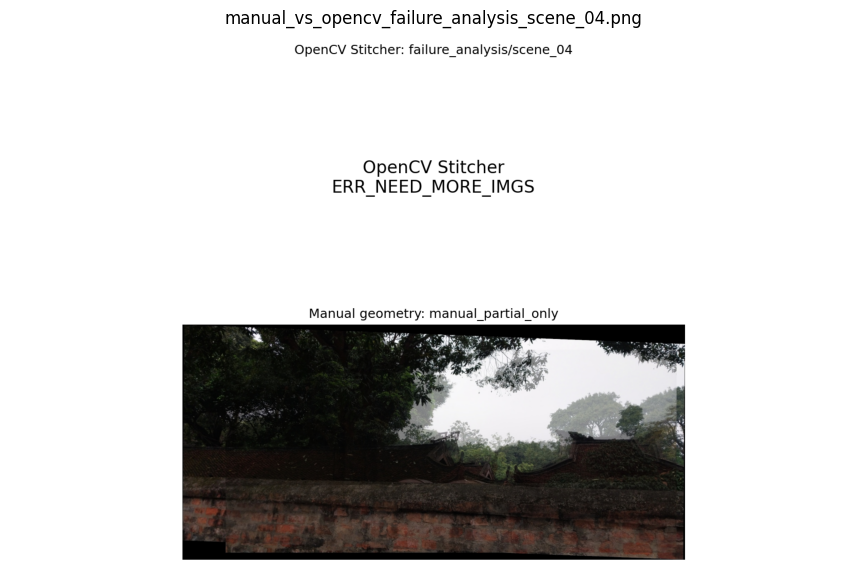

#### `failure_analysis/scene_06` | comparison: `both_ok`

**Scene problems:** sky_dominance, low_texture  
**Scene category:** `hard_valid`  
**Observed stitching result:** OpenCV and manual both produced panoramas; compare seams, canvas size, drift, and ghosting visually.  
**Artifact/glitch to inspect:** few stable anchors, unstable homography, stretched canvas, or weak confidence  
**Scene notes:** Sky-dominant outdoor sequence where the upper half of every frame is almost entirely textureless blue sky. OpenCV can still stitch this version, but one adjacent link is weak/failing and the scene is useful as a low-texture sky stress case.

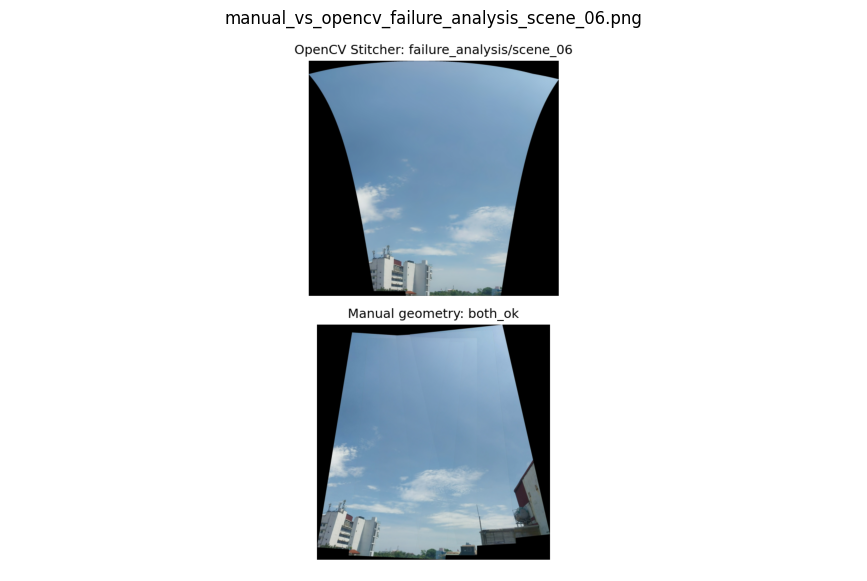

#### `failure_analysis/scene_07` | comparison: `both_ok`

**Scene problems:** zoom_change, scale_change  
**Scene category:** `hard_valid`  
**Observed stitching result:** OpenCV and manual both produced panoramas; compare seams, canvas size, drift, and ghosting visually.  
**Artifact/glitch to inspect:** nan  
**Scene notes:** Outdoor sequence with visible zoom or focal-length change between adjacent frames. Pairwise affine estimates show repeated scale jumps, so it should be treated as a zoom/scale-change stress case rather than a normal rotational panorama.

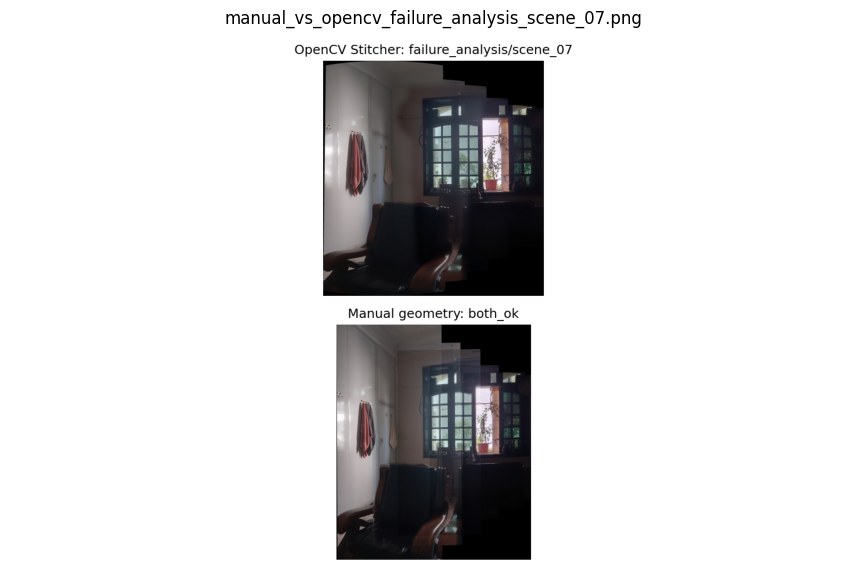

#### `failure_analysis/scene_08` | comparison: `manual_only`

**Scene problems:** global_stitch_failure  
**Scene category:** `failure`  
**Observed stitching result:** OpenCV returned ERR_NEED_MORE_IMGS; manual produced a full-chain output (3/3).  
**Artifact/glitch to inspect:** good adjacent matches can still be rejected during global camera estimation  
**Scene notes:** The remaining 3-image subset has strong adjacent pair matches, but OpenCV Stitcher still rejects the chain with ERR_NEED_MORE_IMGS, so it is better kept as a failure case.

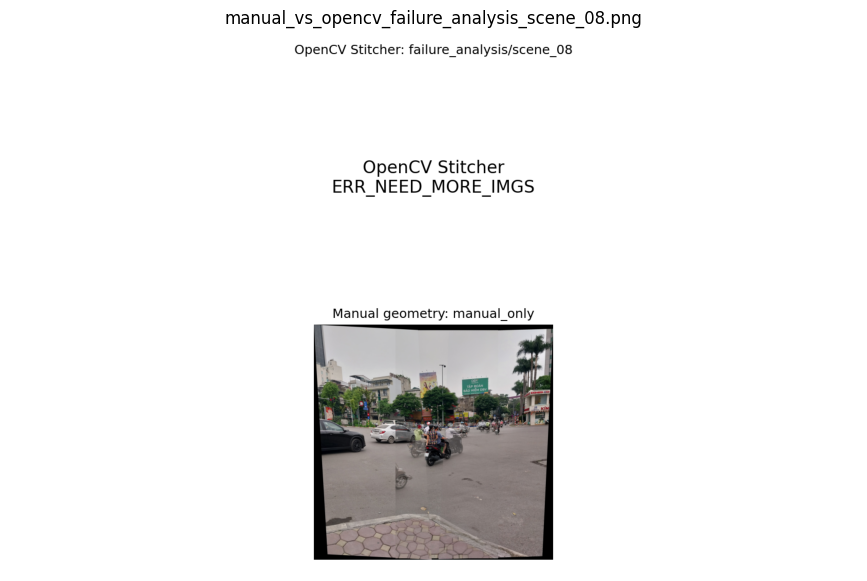

#### `failure_analysis/scene_11` | comparison: `manual_only`

**Scene problems:** low_texture  
**Scene category:** `failure`  
**Observed stitching result:** OpenCV returned ERR_NEED_MORE_IMGS; manual produced a full-chain output (3/3).  
**Artifact/glitch to inspect:** few stable anchors, unstable homography, stretched canvas, or weak confidence  
**Scene notes:** The sequence is shot through a vehicle window over a broad water surface, so most shared content is low-texture and weakly anchored. Stitching fails consistently enough to keep it as a low-texture failure case.

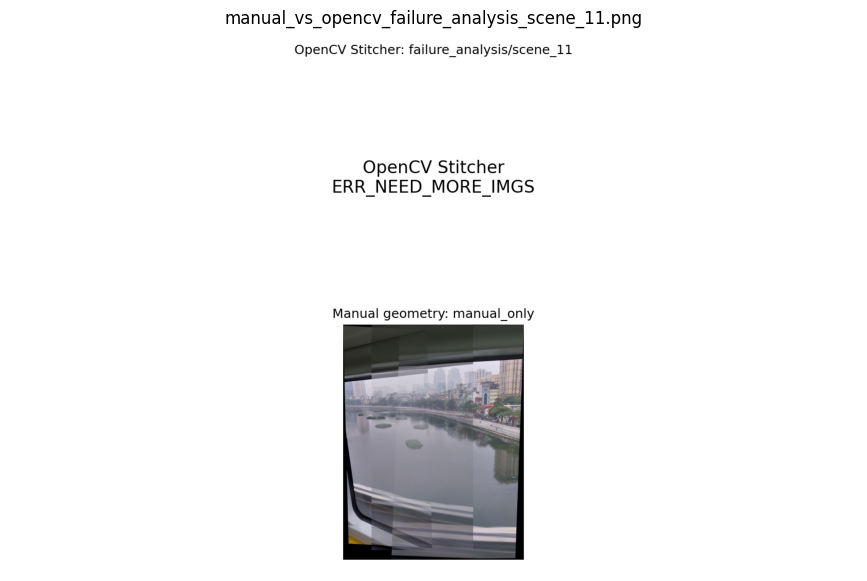

#### `failure_analysis/scene_15` | comparison: `manual_only`

**Scene problems:** insufficient_global_connectivity, insufficient_overlap, parallax, sideways_scan  
**Scene category:** `failure`  
**Observed stitching result:** OpenCV returned ERR_NEED_MORE_IMGS; manual produced a full-chain output (5/5).  
**Artifact/glitch to inspect:** local pairs may connect, but the whole scene can still fail globally; broken image chain, ERR_NEED_MORE_IMGS, missing regions, or forced narrow manual output; ghosting, bent structures, doubled edges, and partial stitching because one homography cannot explain all depths; translation-like capture causes drift and perspective stretching in a manual transform chain  
**Scene notes:** Outdoor sideways scan captured from a moving train, so the sequence is a translated scan rather than a rotational panorama. The adjacent pairs are only moderate and the global chain is not trusted; OpenCV consistently returns ERR_NEED_MORE_IMGS.

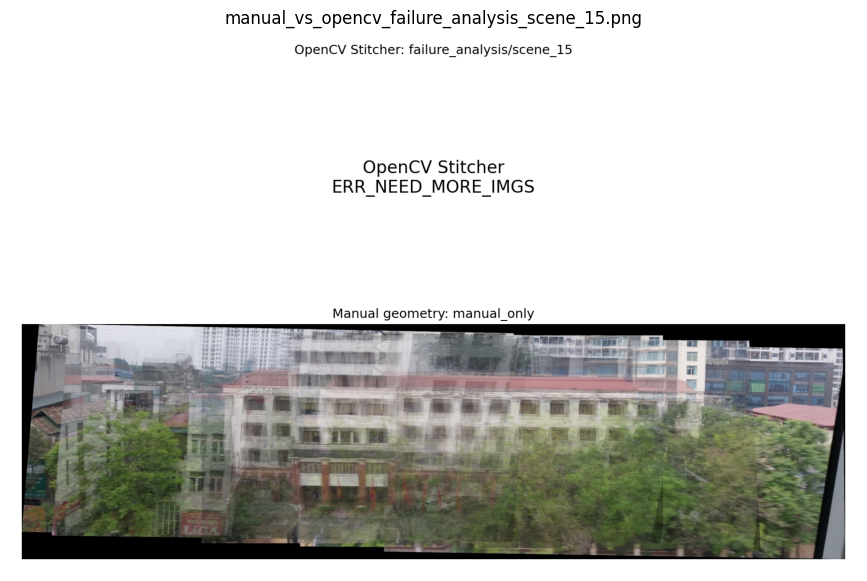

#### `failure_analysis/scene_16` | comparison: `both_ok`

**Scene problems:** camera_translation, vertical_camera_motion, horizontal_camera_motion, parallax  
**Scene category:** `hard_valid`  
**Observed stitching result:** OpenCV and manual both produced panoramas; compare seams, canvas size, drift, and ghosting visually.  
**Artifact/glitch to inspect:** ghosting, bent structures, doubled edges, and partial stitching because one homography cannot explain all depths  
**Scene notes:** Sequence captured with substantial camera translation instead of a mostly rotational sweep. Adjacent transforms show large horizontal motion with smaller vertical drift, making it a vertical/horizontal camera-movement stress case.

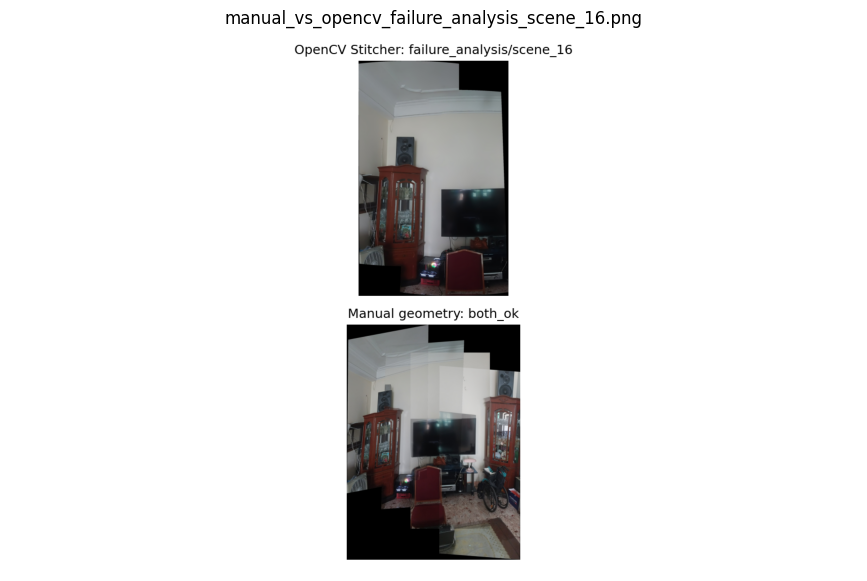

#### `failure_analysis/scene_18` | comparison: `both_failed_or_missing`

**Scene problems:** low_light, exposure_compensation, underexposure, low_texture  
**Scene category:** `failure`  
**Observed stitching result:** OpenCV status=ERR_NEED_MORE_IMGS; manual status=failed.  
**Artifact/glitch to inspect:** few stable anchors, unstable homography, stretched canvas, or weak confidence  
**Scene notes:** Very dark low-light sequence captured with the camera brightness/exposure compensation pushed high. The files do not preserve ISO metadata, so high ISO or sensor gain is not directly verifiable, but this represents a realistic auto-exposure/brightness-boost capture in a dark place. Mean brightness is still extremely low and ORB finds almost no keypoints, causing a stable OpenCV stitch failure.

Missing comparison plot: C:\Users\PC\Downloads\Project\outputs\manual_homography_stitcher\comparison\plots\manual_vs_opencv_failure_analysis_scene_18.png


#### `failure_analysis/scene_21` | comparison: `both_ok`

**Scene problems:** exposure_change, low_texture, wide_sweep  
**Scene category:** `hard_valid`  
**Observed stitching result:** OpenCV and manual both produced panoramas; compare seams, canvas size, drift, and ghosting visually.  
**Artifact/glitch to inspect:** visible brightness seams and inconsistent panorama footprint; few stable anchors, unstable homography, stretched canvas, or weak confidence; accumulated drift and large-canvas output variation; successful stitch still needs visual inspection because output footprint varies  
**Scene notes:** Wide indoor sweep that includes bright doorway views and several low-texture wall and ceiling segments. It usually stitches, but the broad coverage and sparse anchors keep it in hard-valid territory.

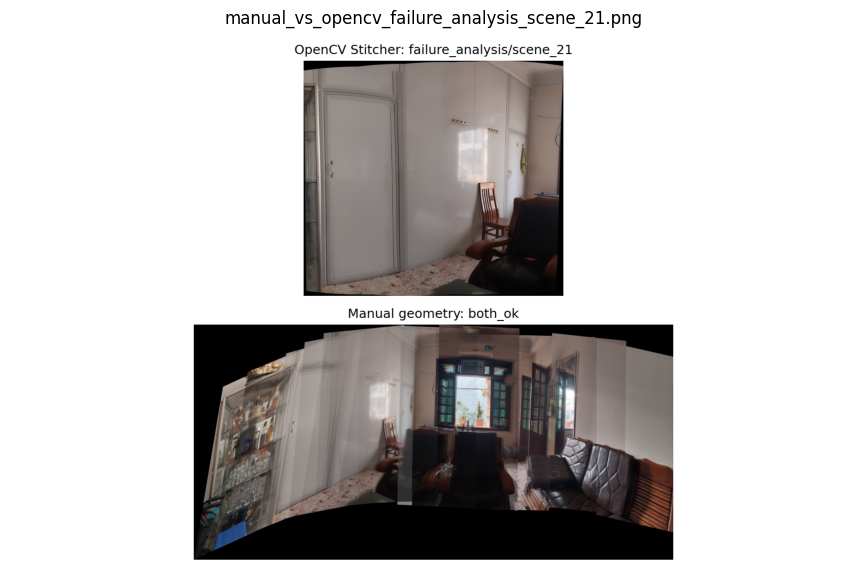

#### `failure_analysis/scene_30` | comparison: `both_ok`

**Scene problems:** exposure_change, output_variation, stitch_instability  
**Scene category:** `hard_valid`  
**Observed stitching result:** OpenCV and manual both produced panoramas; compare seams, canvas size, drift, and ghosting visually.  
**Artifact/glitch to inspect:** visible brightness seams and inconsistent panorama footprint; different runs can produce different crops or output sizes; sensitive panorama footprint and non-repeatable global optimization; successful stitch still needs visual inspection because output footprint varies  
**Scene notes:** Outdoor park walkway sequence at dusk. OpenCV returns OK on every run, but the panorama footprint varies heavily and the sequence moves from brighter park/tree views into darker wall-heavy views, making it a hard-valid exposure and stability case.

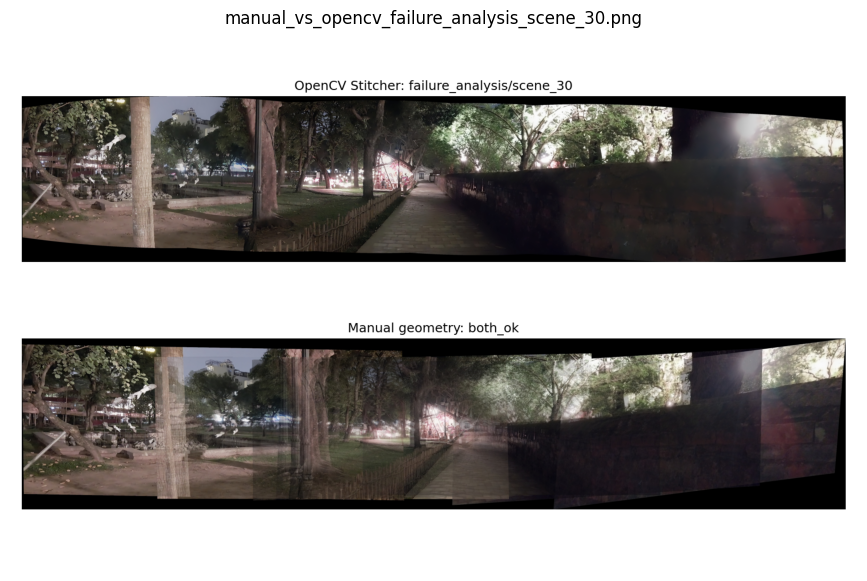

#### `failure_analysis/scene_32` | comparison: `both_ok`

**Scene problems:** repeated_patterns  
**Scene category:** `hard_valid`  
**Observed stitching result:** OpenCV and manual both produced panoramas; compare seams, canvas size, drift, and ghosting visually.  
**Artifact/glitch to inspect:** wrong correspondences or believable but incorrect alignment; successful stitch still needs visual inspection because output footprint varies  
**Scene notes:** Close-range gate sequence dominated by repeated lattice bars and similar red flag shapes. This is the clearest repeated-pattern case in the current failure_analysis split. Pairwise matching is mostly OK/strong and exposure is steady, but repeated OpenCV runs produce different panorama widths, making it a hard-valid repeated-pattern stress case.

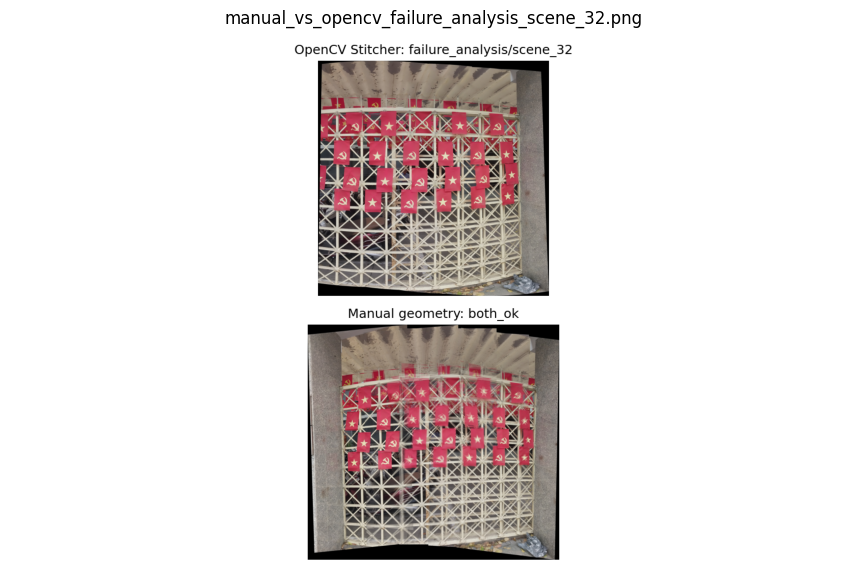

#### `failure_analysis/scene_35` | comparison: `both_ok`

**Scene problems:** motion_blur, moving_objects, output_variation  
**Scene category:** `hard_valid`  
**Observed stitching result:** OpenCV and manual both produced panoramas; compare seams, canvas size, drift, and ghosting visually.  
**Artifact/glitch to inspect:** lower keypoint quality, blurred seams, and unstable matching; ghosting or duplicated moving cars/people; different runs can produce different crops or output sizes; successful stitch still needs visual inspection because output footprint varies  
**Scene notes:** Night street sequence under an overpass with fast moving traffic crossing the field of view. It still stitches, but the vehicle blur and output variation make it a better hard-valid benchmark than a clean success scene.

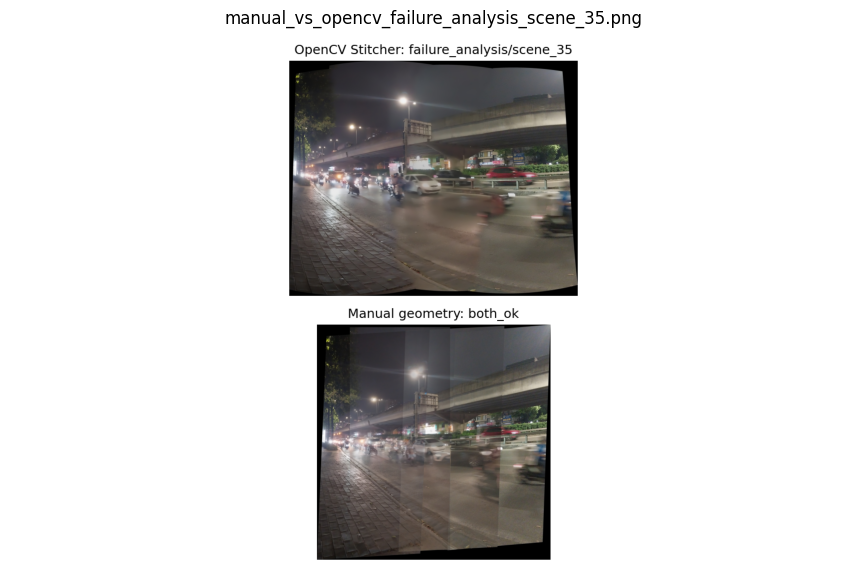

#### `test/scene_01` | comparison: `both_ok`

**Scene problems:** none recorded in meta.json  
**Scene category:** `success`  
**Observed stitching result:** Comparison label: `both_ok`; OpenCV status: `OK`.  
**Artifact/glitch to inspect:** No failure-analysis problem tag recorded for this scene; inspect the panel mainly for normal seam/crop quality.  
**Scene notes:** After splitting the old 12-image chain, this 6-image subset stitches cleanly with five strong adjacent pairs and no broken transition.

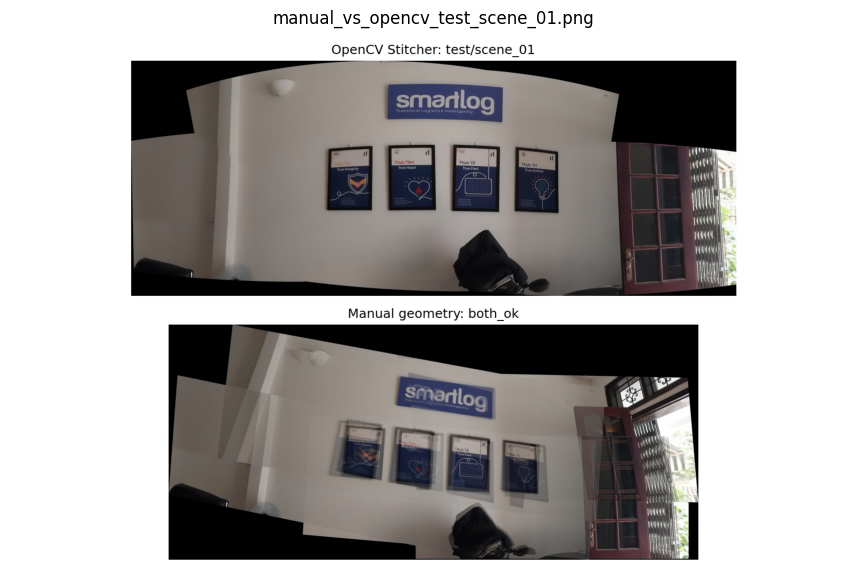

#### `test/scene_24` | comparison: `both_ok`

**Scene problems:** none recorded in meta.json  
**Scene category:** `success`  
**Observed stitching result:** Comparison label: `both_ok`; OpenCV status: `OK`.  
**Artifact/glitch to inspect:** No failure-analysis problem tag recorded for this scene; inspect the panel mainly for normal seam/crop quality.  
**Scene notes:** Another large 30-image scene with uniformly strong adjacent pairs and a successful OpenCV panorama, making it a good large-scene success example.

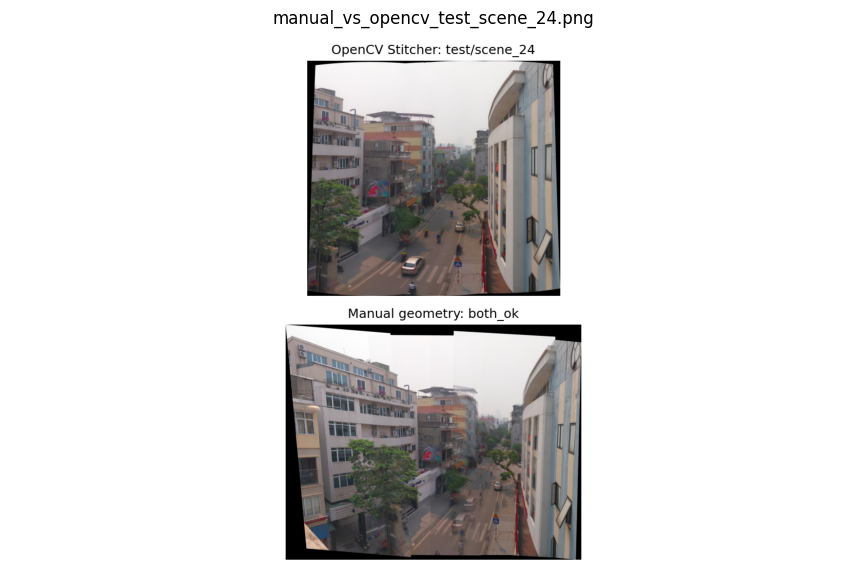

#### `test/scene_28` | comparison: `both_ok_manual_partial`

**Scene problems:** none recorded in meta.json  
**Scene category:** `success`  
**Observed stitching result:** Comparison label: `both_ok_manual_partial`; OpenCV status: `OK`.  
**Artifact/glitch to inspect:** No failure-analysis problem tag recorded for this scene; inspect the panel mainly for normal seam/crop quality.  
**Scene notes:** none

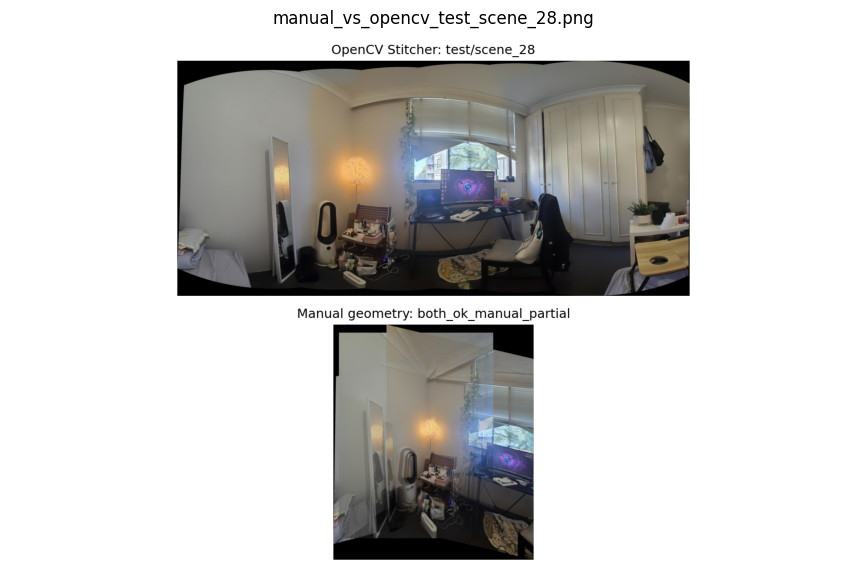

#### `test/scene_33` | comparison: `both_ok_manual_partial`

**Scene problems:** repeated_patterns  
**Scene category:** `success`  
**Observed stitching result:** Comparison label: `both_ok_manual_partial`; OpenCV status: `OK`.  
**Artifact/glitch to inspect:** No failure-analysis problem tag recorded for this scene; inspect the panel mainly for normal seam/crop quality.  
**Scene notes:** Night outdoor gate/fence sequence. The fence introduces repeated vertical bars and lighting changes across the sweep, but the adjacent pairs remain usable and the stability check is a clean stable_success, so this is a medium success benchmark.

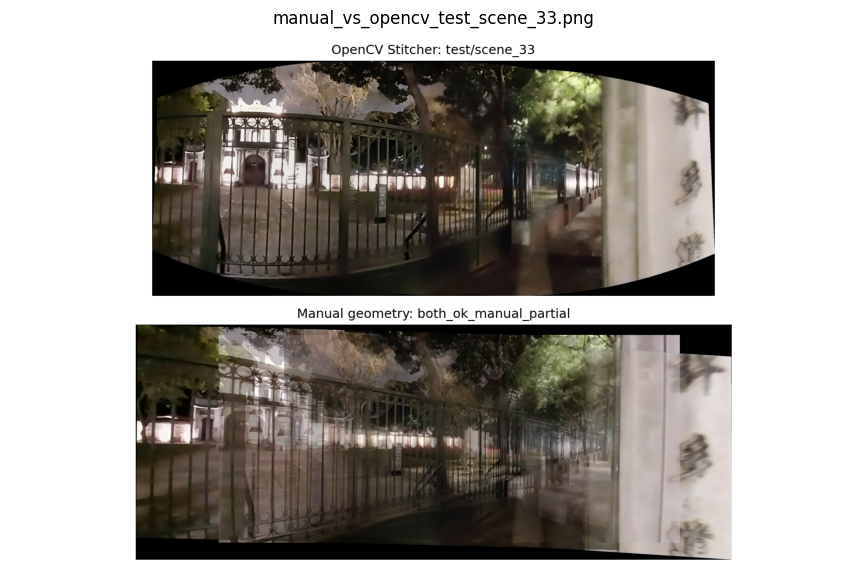

#### `test/scene_36` | comparison: `manual_only`

**Scene problems:** motion_blur, moving_objects, output_variation, parallax, translation_capture  
**Scene category:** `hard_valid`  
**Observed stitching result:** Comparison label: `manual_only`; OpenCV status: `ERR_CAMERA_PARAMS_ADJUST_FAIL`.  
**Artifact/glitch to inspect:** No failure-analysis problem tag recorded for this scene; inspect the panel mainly for normal seam/crop quality.  
**Scene notes:** Night sidewalk capture under an overpass with heavy moving traffic and a walking-style translated viewpoint. OpenCV usually succeeds, but motion blur, moving objects, and mild output variation keep it in hard-valid territory.

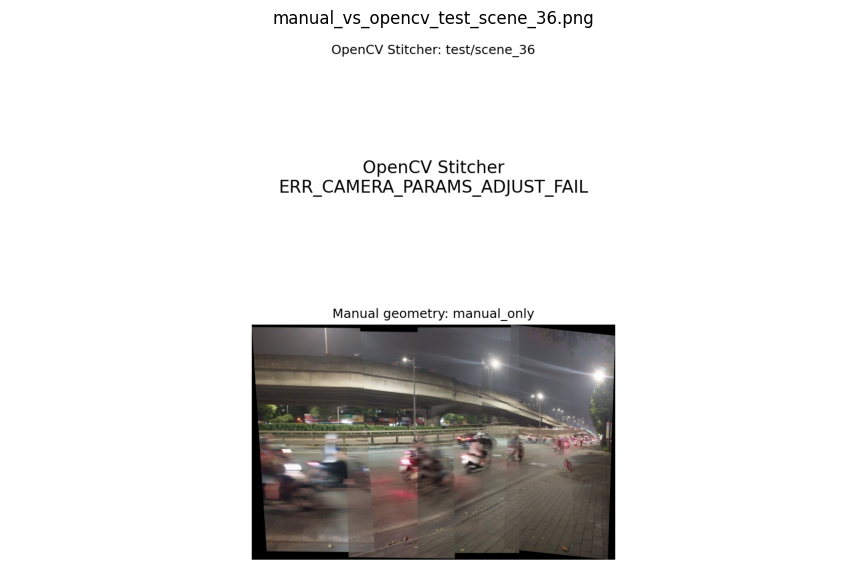

#### `test/scene_40` | comparison: `both_ok`

**Scene problems:** exposure_change, moving_objects, parallax, translation_capture  
**Scene category:** `success`  
**Observed stitching result:** Comparison label: `both_ok`; OpenCV status: `OK`.  
**Artifact/glitch to inspect:** No failure-analysis problem tag recorded for this scene; inspect the panel mainly for normal seam/crop quality.  
**Scene notes:** Scene has 8 images and stitches very stably 10/10 times. Pair 4 is a weak link with only 18 inliers (0.32 ratio), but the overall chain is robust enough to produce a highly consistent panorama.

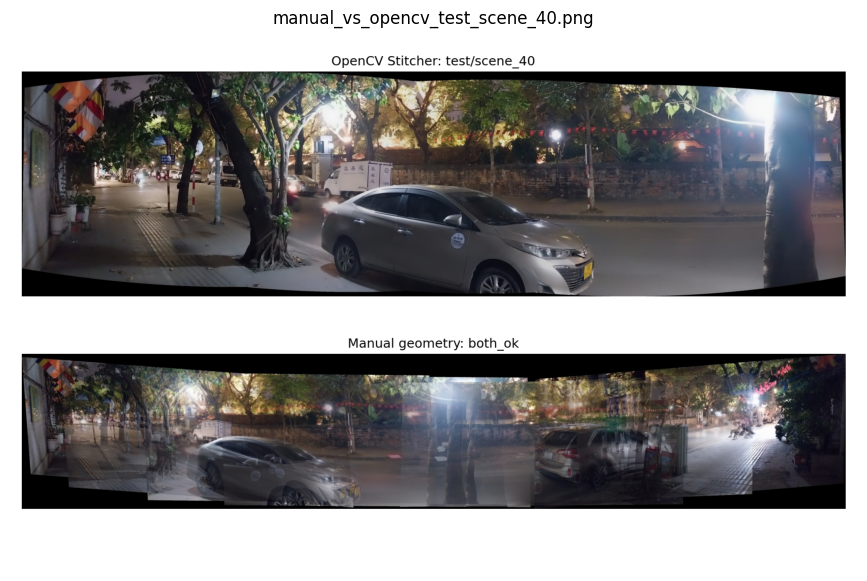

In [36]:
def show_comparison_plot(filename: str, figsize: tuple[int, int] = (13, 7)) -> None:
    path = COMPARISON_OUTPUT_DIR / "plots" / filename
    if not path.exists():
        print("Missing comparison plot:", path)
        return
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        print("Could not read comparison plot:", path)
        return
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    plt.axis("off")
    plt.title(filename)
    plt.show()


def comparison_plot_name(row: pd.Series) -> str:
    return f"manual_vs_opencv_{row['split']}_{row['scene_id']}.png"


PROBLEM_FLAG_FIELDS = [
    "has_moving_objects",
    "has_repeated_patterns",
    "has_low_texture",
    "has_parallax",
    "has_exposure_change",
    "has_motion_blur",
    "has_insufficient_overlap",
]


def read_scene_problem_tags(split_name: str, scene_id: str) -> tuple[str, str, str]:
    meta_path = SPLIT_ROOT / split_name / scene_id / "meta.json"
    if not meta_path.exists():
        return "", "", ""
    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    issues = [str(issue) for issue in meta.get("issues", []) if str(issue).strip()]
    active_flags = [field.removeprefix("has_") for field in PROBLEM_FLAG_FIELDS if meta.get(field) is True]
    combined = []
    for value in issues + active_flags:
        if value not in combined:
            combined.append(value)
    return ", ".join(combined), meta.get("category", ""), meta.get("notes", "")


def failure_problem_lookup() -> dict[tuple[str, str], dict]:
    if "failure_problem_df" not in globals():
        csv_path = PROJECT_ROOT / "outputs" / "failure_problem_analysis" / "failure_problem_stitching_summary.csv"
        if csv_path.exists():
            lookup_df = pd.read_csv(csv_path)
        else:
            return {}
    else:
        lookup_df = failure_problem_df
    return {
        (str(row["split"]), str(row["scene_id"])): row.to_dict()
        for _, row in lookup_df.iterrows()
    }


def display_scene_problem_note(row: pd.Series, lookup: dict[tuple[str, str], dict]) -> None:
    split_name = str(row["split"])
    scene_id = str(row["scene_id"])
    problem_row = lookup.get((split_name, scene_id), {})

    if problem_row:
        issues = str(problem_row.get("issues", "")).strip()
        category = str(problem_row.get("category", "")).strip()
        observed = str(problem_row.get("observed_stitching_result", "")).strip()
        likely = str(problem_row.get("likely_glitch_or_error", "")).strip()
        notes = str(problem_row.get("notes", "")).strip()
    else:
        issues, category, notes = read_scene_problem_tags(split_name, scene_id)
        observed = f"Comparison label: `{row['comparison_status']}`; OpenCV status: `{row['opencv_status_name']}`."
        likely = "No failure-analysis problem tag recorded for this scene; inspect the panel mainly for normal seam/crop quality."

    if not issues:
        issues = "none recorded in meta.json"
    if not category:
        category = "not recorded"
    if not notes:
        notes = "none"

    display(
        Markdown(
            f"#### `{split_name}/{scene_id}` | comparison: `{row['comparison_status']}`\n\n"
            f"**Scene problems:** {issues}  \n"
            f"**Scene category:** `{category}`  \n"
            f"**Observed stitching result:** {observed}  \n"
            f"**Artifact/glitch to inspect:** {likely}  \n"
            f"**Scene notes:** {notes}"
        )
    )


problem_lookup = failure_problem_lookup()

if HAS_MATPLOTLIB:
    # Summary plots first.
    for filename in [
        "manual_vs_opencv_status_counts.png",
        "manual_vs_opencv_area.png",
        "manual_runtime_by_scene.png",
    ]:
        show_comparison_plot(filename, figsize=(13, 6))

    # Then show every scene panorama comparison generated by the comparison script.
    scene_rows = list(comparison_df.iterrows())
    display(Markdown(f"### Showing all {len(scene_rows)} stitched panorama comparison panels with scene-problem notes"))
    for _, row in scene_rows:
        display_scene_problem_note(row, problem_lookup)
        show_comparison_plot(comparison_plot_name(row), figsize=(13, 7))
else:
    display_rows = []
    for _, row in comparison_df.iterrows():
        split_name = str(row["split"])
        scene_id = str(row["scene_id"])
        problem_row = problem_lookup.get((split_name, scene_id), {})
        issues, category, notes = read_scene_problem_tags(split_name, scene_id)
        display_rows.append(
            {
                **row.to_dict(),
                "scene_problems": problem_row.get("issues", issues),
                "likely_glitch_or_error": problem_row.get("likely_glitch_or_error", ""),
            }
        )
    display(pd.DataFrame(display_rows)[["split", "scene_id", "scene_problems", "comparison_status", "opencv_status_name", "manual_panorama_path", "likely_glitch_or_error"]])

### Comparison Notes

- The final visualization cell now displays every scene in `comparison_df`, so the showcase includes all stitched panorama panels from `test` and `failure_analysis`.
- `both_ok` means both methods produced a full-scene panorama.
- `manual_only` means OpenCV returned an error while the manual adjacent-transform chain still produced an output. These outputs must be checked visually because the manual method does not do global camera adjustment, seam finding, or exposure compensation.
- `manual_partial_only` means OpenCV failed and the manual pipeline saved only a valid sub-chain. This is useful for diagnosis, not a complete scene success.
- Large canvas-area differences are expected: OpenCV estimates a global camera model and crops/warps differently, while the manual method directly chains adjacent transforms on a common canvas.
